#1. Adhi's Demo to Show Experience working with SSA data.

#CASE STUDY = LEO Satellite Missed-Thrust Event (MTE) and Rapid Conjunction Assessment with Real Time SSA Data


### Say, we have a satellite currently in orbit. Like the AOBA VELOX-IV, this satellite is also likely a Low Thrust (LT) vehicle. Such devices are prone to Missed Thrust Events (MTE). When an MTE occurs, decisions need to made quick! How soon can we fix the root cause? how much ballistic period can we afford? do we have sufficient delta_v budget to recover? Which candidate trajectories will minimise risk of collision?! and so forth...

### This demo includes my original invention - the Phase Guess algorithm -  to rapidly solve TPBVPs and generate 100s of candidate trajectories. Other works featured here are from JPL and NASA.

###Enjoy!

In [ ]:
# @title
# --- Block 1: notebook setup, dependencies, and notebook reporting utilities ---

%pip -q install sgp4

import io
import math
from pathlib import Path
from urllib.parse import urlencode

import numpy as np
import pandas as pd
import requests

from IPython.display import Markdown, display
from sgp4.api import Satrec

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

def _fmt_value(v):
    if isinstance(v, float):
        return f"{v:.6g}"
    if isinstance(v, (list, tuple, np.ndarray)):
        return ", ".join(str(x) for x in v)
    return str(v)

def _dict_to_md_table(d: dict, left_col: str = "Item", right_col: str = "Value") -> str:
    rows = [f"| {left_col} | {right_col} |", "|---|---|"]
    for k, v in d.items():
        rows.append(f"| {k} | {_fmt_value(v)} |")
    return "\n".join(rows)

def display_block_report(
    block_id: int,
    title: str,
    capability: str,
    equations: list[str] | None = None,
    hyperparams: dict | None = None,
    outputs: dict | None = None,
):
    parts = [f"##{title}", f"**Capability**  \n{capability}"]

    if equations:
        eq_lines = "\n".join([f"- `{eq}`" for eq in equations])
        parts.append(f"**Equations used**  \n{eq_lines}")

    if hyperparams:
        parts.append("**Hyperparameters**")
        parts.append(_dict_to_md_table(hyperparams, "Parameter", "Value"))

    if outputs:
        parts.append("**Outputs**")
        parts.append(_dict_to_md_table(outputs, "Output", "Value"))

    display(Markdown("\n\n".join(parts)))

display(Markdown(r"""
## README

**Operator spacecraft:** Tanager-1
**SSA data source:** CelesTrak GP / TLE
**Mission context:** low-thrust LEO orbit control with missed-thrust event recovery
**Decision products:** recovery search space, Pareto front, SSA screening metrics

### Notebook scope
1. ingest operator and catalog TLE data
2. build an SSA-relevant local catalog around the operator
3. simulate missed thrust event, propagate TLEs and compute miss-distance screening metrics
4. build RTN-frame relative dynamics around the operator
5. generate a recovery search space using Phase Guess algorithm (invented by Adhi)
6. identify conjunction-aware recovery options by evaluating candidate recoveries against the SSA catalog

### References used in this notebook
1. Phase Guess algorithm (Saxena, Ornik, Eggl 2025, UIUC)
2. Missed-thrust framework (Karn et. al. 2026, NASA)
3. Multi-objective missed-thrust optimization using Pareto front logic (Venigalla et al. 2024, JPL)
4. Planet Labs Tanager documentation
5. CelesTrak GP query documentation
"""))


## README

**Operator spacecraft:** Tanager-1  
**SSA data source:** CelesTrak GP / TLE  
**Mission context:** low-thrust LEO orbit control with missed-thrust event recovery  
**Decision products:** recovery search space, Pareto front, SSA screening metrics

### Notebook scope
1. ingest operator and catalog TLE data  
2. build an SSA-relevant local catalog around the operator  
3. simulate missed thrust event, propagate TLEs and compute miss-distance screening metrics  
4. build RTN-frame relative dynamics around the operator  
5. generate a recovery search space using Phase Guess algorithm (invented by Adhi)
6. identify conjunction-aware recovery options by evaluating candidate recoveries against the SSA catalog

### References used in this notebook
1. Phase Guess algorithm (Saxena, Ornik, Eggl 2025, UIUC)
2. Missed-thrust framework (Karn et. al. 2026, NASA)
3. Multi-objective missed-thrust optimization using Pareto front logic (Venigalla et al. 2024, JPL)
4. Planet Labs Tanager documentation
5. CelesTrak GP query documentation


#2

In [ ]:
# @title
# --- Block 2: configuration, local cache, and CelesTrak data ingest ---

CACHE_DIR = Path("/content/mte_ssa_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "operator_name": "TANAGER-1",
    "operator_catnr": 60507,
    "catalog_group": "ACTIVE",
    "default_step_seconds": 60,
    "local_catalog_target_size": 1500,
    "screening_window_orbits": 3,
    "force_refresh": False,
    "http_timeout_seconds": 30,
}

BASE_GP_URL = "https://celestrak.org/NORAD/elements/gp.php"
HTTP_HEADERS = {
    "User-Agent": "mte-ssa-prototype/0.1 (Google Colab)",
}

session = requests.Session()
session.headers.update(HTTP_HEADERS)

def build_celestrak_url(**params) -> str:
    clean_params = {k: v for k, v in params.items() if v is not None}
    return f"{BASE_GP_URL}?{urlencode(clean_params)}"

def fetch_text_with_cache(url: str, cache_path: Path, force_refresh: bool = False) -> str:
    if cache_path.exists() and not force_refresh:
        return cache_path.read_text(encoding="utf-8")

    response = session.get(url, timeout=CONFIG["http_timeout_seconds"])
    response.raise_for_status()
    text = response.text

    if not text.strip():
        raise ValueError(f"Empty response from {url}")

    cache_path.write_text(text, encoding="utf-8")
    return text

operator_tle_url = build_celestrak_url(CATNR=CONFIG["operator_catnr"], FORMAT="TLE")
operator_tle_path = CACHE_DIR / "tanager1.tle"
operator_tle_text = fetch_text_with_cache(
    operator_tle_url,
    operator_tle_path,
    force_refresh=CONFIG["force_refresh"],
)

tle_lines = [line.strip() for line in operator_tle_text.splitlines() if line.strip()]
if len(tle_lines) < 3:
    raise ValueError("Expected a 3-line TLE response for the operator vehicle.")

OPERATOR_TLE = {
    "name": tle_lines[0],
    "line1": tle_lines[1],
    "line2": tle_lines[2],
}

active_csv_url = build_celestrak_url(GROUP=CONFIG["catalog_group"], FORMAT="CSV")
active_csv_path = CACHE_DIR / f"{CONFIG['catalog_group'].lower()}_catalog.csv"
active_csv_text = fetch_text_with_cache(
    active_csv_url,
    active_csv_path,
    force_refresh=CONFIG["force_refresh"],
)

CATALOG_RAW = pd.read_csv(io.StringIO(active_csv_text))
CATALOG_RAW.columns = [str(c).strip().upper() for c in CATALOG_RAW.columns]

required_cols = {
    "OBJECT_NAME",
    "NORAD_CAT_ID",
    "EPOCH",
    "MEAN_MOTION",
    "ECCENTRICITY",
    "INCLINATION",
    "RA_OF_ASC_NODE",
    "ARG_OF_PERICENTER",
    "MEAN_ANOMALY",
    "BSTAR",
}
missing_cols = sorted(required_cols.difference(CATALOG_RAW.columns))
if missing_cols:
    raise KeyError(f"Active GP catalog is missing required columns: {missing_cols}")

display_block_report(
    block_id=2,
    title="TLE Data Ingestion from CelesTrak",
    capability=(
        "Fetch operator TLE by NORAD catalog ID and fetch the active GP (SGP4 supported) catalog from CelesTrak. "
        "Cache responses locally for repeatable runs."
    ),
    equations=[
        "HTTP GET: gp.php?CATNR=<id>&FORMAT=TLE",
        "HTTP GET: gp.php?GROUP=<group>&FORMAT=CSV",
    ],
    hyperparams={
        "operator_name": CONFIG["operator_name"],
        "operator_catnr": CONFIG["operator_catnr"],
        "catalog_group": CONFIG["catalog_group"],
        "default_step_seconds": CONFIG["default_step_seconds"],
        "local_catalog_target_size": CONFIG["local_catalog_target_size"],
        "screening_window_orbits": CONFIG["screening_window_orbits"],
        "http_timeout_seconds": CONFIG["http_timeout_seconds"],
        "force_refresh": CONFIG["force_refresh"],
    },
    outputs={
        "operator_tle_name": OPERATOR_TLE["name"],
        "raw_catalog_rows": len(CATALOG_RAW),
        "required_columns_verified": True,
    },
)

print("Operator TLE")
print(OPERATOR_TLE["name"])
#print(OPERATOR_TLE["line1"])
#print(OPERATOR_TLE["line2"])

display(CATALOG_RAW.head(3))

##TLE Data Ingestion from CelesTrak

**Capability**  
Fetch operator TLE by NORAD catalog ID and fetch the active GP (SGP4 supported) catalog from CelesTrak. Cache responses locally for repeatable runs.

**Equations used**  
- `HTTP GET: gp.php?CATNR=<id>&FORMAT=TLE`
- `HTTP GET: gp.php?GROUP=<group>&FORMAT=CSV`

**Hyperparameters**

| Parameter | Value |
|---|---|
| operator_name | TANAGER-1 |
| operator_catnr | 60507 |
| catalog_group | ACTIVE |
| default_step_seconds | 60 |
| local_catalog_target_size | 1500 |
| screening_window_orbits | 3 |
| http_timeout_seconds | 30 |
| force_refresh | False |

**Outputs**

| Output | Value |
|---|---|
| operator_tle_name | TANAGER-1 |
| raw_catalog_rows | 15136 |
| required_columns_verified | True |

Operator TLE
TANAGER-1


,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2026-04-18T04:33:38.026080,13.765508,0.002785,90.2207,70.3595,110.5957,266.7887,0,U,900,999,6317,0.000524,5.240000e-06,0.0
1,CALSPHERE 2,1964-063E,2026-04-18T04:31:54.231168,13.528952,0.002009,90.2331,74.3567,45.9888,330.9001,0,U,902,999,84815,0.000043,3.800000e-07,0.0
2,LCS 1,1965-034C,2026-04-17T23:44:03.783552,9.893100,0.001331,32.1453,319.9613,268.3965,91.5007,0,U,1361,999,20392,0.000215,1.000000e-07,0.0


#3

In [ ]:
# @title
# --- Block 3: orbital-element normalization and local SSA prefilter ---

MU_EARTH_KM3_S2 = 398600.4418
R_EARTH_KM = 6378.137

def to_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def wrap_angle_delta_deg(a_deg: pd.Series, b_deg: float) -> pd.Series:
    return np.abs((a_deg - b_deg + 180.0) % 360.0 - 180.0)

def mean_motion_to_semimajor_axis_km(mean_motion_rev_day: pd.Series) -> pd.Series:
    n_rad_s = mean_motion_rev_day * (2.0 * np.pi / 86400.0)
    return (MU_EARTH_KM3_S2 / (n_rad_s ** 2)) ** (1.0 / 3.0)

CATALOG = CATALOG_RAW.copy()

numeric_cols = [
    "NORAD_CAT_ID",
    "MEAN_MOTION",
    "ECCENTRICITY",
    "INCLINATION",
    "RA_OF_ASC_NODE",
    "ARG_OF_PERICENTER",
    "MEAN_ANOMALY",
    "BSTAR",
]
for col in numeric_cols:
    CATALOG[col] = to_numeric(CATALOG[col])

CATALOG["EPOCH"] = pd.to_datetime(CATALOG["EPOCH"], utc=True, errors="coerce")
CATALOG = CATALOG.dropna(
    subset=["NORAD_CAT_ID", "MEAN_MOTION", "ECCENTRICITY", "INCLINATION", "RA_OF_ASC_NODE"]
).copy()
CATALOG["NORAD_CAT_ID"] = CATALOG["NORAD_CAT_ID"].astype(int)

CATALOG["SEMIMAJOR_AXIS_KM"] = mean_motion_to_semimajor_axis_km(CATALOG["MEAN_MOTION"])
CATALOG["PERIGEE_ALT_KM"] = CATALOG["SEMIMAJOR_AXIS_KM"] * (1.0 - CATALOG["ECCENTRICITY"]) - R_EARTH_KM
CATALOG["APOGEE_ALT_KM"] = CATALOG["SEMIMAJOR_AXIS_KM"] * (1.0 + CATALOG["ECCENTRICITY"]) - R_EARTH_KM
CATALOG["PERIOD_MIN"] = 1440.0 / CATALOG["MEAN_MOTION"]

operator_mask = CATALOG["NORAD_CAT_ID"] == CONFIG["operator_catnr"]
if operator_mask.sum() != 1:
    raise ValueError(
        f"Expected exactly one operator row in the active catalog for CATNR={CONFIG['operator_catnr']}, "
        f"found {operator_mask.sum()}."
    )

OPERATOR_ROW = CATALOG.loc[operator_mask].iloc[0].copy()

CATALOG["DELTA_INC_DEG"] = np.abs(CATALOG["INCLINATION"] - OPERATOR_ROW["INCLINATION"])
CATALOG["DELTA_RAAN_DEG"] = wrap_angle_delta_deg(
    CATALOG["RA_OF_ASC_NODE"],
    float(OPERATOR_ROW["RA_OF_ASC_NODE"]),
)
CATALOG["DELTA_MEAN_MOTION"] = np.abs(CATALOG["MEAN_MOTION"] - OPERATOR_ROW["MEAN_MOTION"])
CATALOG["DELTA_PERIGEE_ALT_KM"] = np.abs(CATALOG["PERIGEE_ALT_KM"] - OPERATOR_ROW["PERIGEE_ALT_KM"])
CATALOG["DELTA_APOGEE_ALT_KM"] = np.abs(CATALOG["APOGEE_ALT_KM"] - OPERATOR_ROW["APOGEE_ALT_KM"])

ALTITUDE_GATE_KM = 100.0
INCLINATION_GATE_DEG = 5.0
RAAN_GATE_DEG = 30.0
MEAN_MOTION_GATE_REV_DAY = 0.35

radial_overlap_gate = (
    (np.abs(CATALOG["PERIGEE_ALT_KM"] - OPERATOR_ROW["APOGEE_ALT_KM"]) <= ALTITUDE_GATE_KM) |
    (np.abs(CATALOG["APOGEE_ALT_KM"] - OPERATOR_ROW["PERIGEE_ALT_KM"]) <= ALTITUDE_GATE_KM) |
    (np.abs(CATALOG["PERIGEE_ALT_KM"] - OPERATOR_ROW["PERIGEE_ALT_KM"]) <= ALTITUDE_GATE_KM) |
    (np.abs(CATALOG["APOGEE_ALT_KM"] - OPERATOR_ROW["APOGEE_ALT_KM"]) <= ALTITUDE_GATE_KM)
)

broad_gate = (
    (CATALOG["NORAD_CAT_ID"] != CONFIG["operator_catnr"]) &
    radial_overlap_gate &
    (CATALOG["DELTA_INC_DEG"] <= INCLINATION_GATE_DEG) &
    (CATALOG["DELTA_RAAN_DEG"] <= RAAN_GATE_DEG) &
    (CATALOG["DELTA_MEAN_MOTION"] <= MEAN_MOTION_GATE_REV_DAY)
)

LOCAL_CATALOG = CATALOG.loc[broad_gate].copy().reset_index(drop=True)

display_block_report(
    block_id=3,
    title="Orbital-Element Normalization and Closest Conjunction Potential Filter",
    capability=(
        "Convert GP fields into derived orbital quantities and prefilter the active catalog to objects with closest conjunction potential based on orbital overlap and relative motion."
    ),
    equations=[
        "a = (mu / n^2)^(1/3)",
        "h_p = a(1 - e) - R_E",
        "h_a = a(1 + e) - R_E",
        #"T_min = 1440 / n_rev_per_day",
        #"Delta(theta) = abs(((theta1 - theta2 + 180) mod 360) - 180)",
        "Prefilter condition: |h_p1 - h_a2| < eps OR |h_a1 - h_p2| < eps",
        "Conjunction relevance metric: d_min ≈ min_t || r_obj(t) - r_op(t) ||",
    ],
    hyperparams={
        "altitude_gate_km": ALTITUDE_GATE_KM,
        "inclination_gate_deg": INCLINATION_GATE_DEG,
        "raan_gate_deg": RAAN_GATE_DEG,
        "mean_motion_gate_rev_day": MEAN_MOTION_GATE_REV_DAY,
    },
    outputs={
        "operator_name": OPERATOR_ROW["OBJECT_NAME"],
        "operator_catnr": int(OPERATOR_ROW["NORAD_CAT_ID"]),
        "operator_period_min": float(OPERATOR_ROW["PERIOD_MIN"]),
        "operator_perigee_alt_km": float(OPERATOR_ROW["PERIGEE_ALT_KM"]),
        "operator_apogee_alt_km": float(OPERATOR_ROW["APOGEE_ALT_KM"]),
        "prefilter_catalog_size": len(LOCAL_CATALOG),
    },
)
print("\n\nPREVIEW - HEAD(10)")
preview_cols = [
    "OBJECT_NAME",
    "NORAD_CAT_ID",
    "EPOCH",
    "INCLINATION",
    "RA_OF_ASC_NODE",
    "MEAN_MOTION",
    "PERIGEE_ALT_KM",
    "APOGEE_ALT_KM",
    "DELTA_INC_DEG",
    "DELTA_RAAN_DEG",
]
display(LOCAL_CATALOG[preview_cols].head(10))

OPERATOR_SUMMARY = {
    "name": str(OPERATOR_ROW["OBJECT_NAME"]),
    "catnr": int(OPERATOR_ROW["NORAD_CAT_ID"]),
    "epoch": OPERATOR_ROW["EPOCH"],
    "inclination_deg": float(OPERATOR_ROW["INCLINATION"]),
    "mean_motion_rev_day": float(OPERATOR_ROW["MEAN_MOTION"]),
    "period_min": float(OPERATOR_ROW["PERIOD_MIN"]),
    "perigee_alt_km": float(OPERATOR_ROW["PERIGEE_ALT_KM"]),
    "apogee_alt_km": float(OPERATOR_ROW["APOGEE_ALT_KM"]),
}

##Orbital-Element Normalization and Closest Conjunction Potential Filter

**Capability**  
Convert GP fields into derived orbital quantities and prefilter the active catalog to objects with closest conjunction potential based on orbital overlap and relative motion.

**Equations used**  
- `a = (mu / n^2)^(1/3)`
- `h_p = a(1 - e) - R_E`
- `h_a = a(1 + e) - R_E`
- `Prefilter condition: |h_p1 - h_a2| < eps OR |h_a1 - h_p2| < eps`
- `Conjunction relevance metric: d_min ≈ min_t || r_obj(t) - r_op(t) ||`

**Hyperparameters**

| Parameter | Value |
|---|---|
| altitude_gate_km | 100 |
| inclination_gate_deg | 5 |
| raan_gate_deg | 30 |
| mean_motion_gate_rev_day | 0.35 |

**Outputs**

| Output | Value |
|---|---|
| operator_name | TANAGER-1 |
| operator_catnr | 60507 |
| operator_period_min | 93.2578 |
| operator_perigee_alt_km | 428.797 |
| operator_apogee_alt_km | 439.214 |
| prefilter_catalog_size | 694 |



PREVIEW - HEAD(10)


,OBJECT_NAME,NORAD_CAT_ID,EPOCH,INCLINATION,RA_OF_ASC_NODE,MEAN_MOTION,PERIGEE_ALT_KM,APOGEE_ALT_KM,DELTA_INC_DEG,DELTA_RAAN_DEG
0,SHIYAN-1 (SY-1),28220,2026-04-18 03:08:04.237440+00:00,97.8707,182.3690,15.322039,465.689447,472.787025,0.5175,19.7657
1,REIMEI (INDEX),28810,2026-04-18 07:28:55.445376+00:00,98.0056,229.5642,15.103199,522.267742,548.179432,0.6524,27.4295
2,SAR-LUPE 2,31797,2026-04-18 05:47:22.163136+00:00,98.1001,205.6183,15.441001,427.192753,440.854268,0.7469,3.4836
3,WORLDVIEW-1 (WV-1),32060,2026-04-18 05:28:02.614656+00:00,97.3874,228.8128,15.242193,492.327449,493.934226,0.0342,26.6781
4,BUGSAT-1 (TITA),40014,2026-04-18 06:33:40.495968+00:00,98.0411,197.3555,15.149805,501.170238,540.905484,0.6879,4.7792
5,ASNARO,40298,2026-04-18 05:38:48.726816+00:00,97.3469,185.9561,15.195082,504.889056,509.762449,0.0063,16.1786
6,ZIYUAN 3-02 (ZY 3-02),41556,2026-04-18 06:28:56.205408+00:00,97.3851,185.1879,15.211813,492.822523,511.730174,0.0319,16.9468
7,JILIN-1 04,43022,2026-04-18 05:48:08.087328+00:00,97.4800,216.3510,15.409127,440.017768,446.810668,0.1268,14.2163
8,JILIN-1 05,43023,2026-04-18 06:44:33.996192+00:00,97.4810,213.6892,15.329916,462.320494,471.464495,0.1278,11.5545
9,JILIN-1 06,43024,2026-04-18 06:00:38.785824+00:00,97.4740,210.7302,15.330086,461.025399,472.658441,0.1208,8.5955


#4

In [ ]:
# @title
# --- Block 4: attach TLEs, build SGP4 records, and compute miss-distance screening metrics ---
print("This block may take 60-70 seconds to complete all CelesTrak fetch requests (1500 for this demo)....")

from sgp4.api import jday, SGP4_ERRORS

def ensure_utc_timestamp(ts) -> pd.Timestamp:
    ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")
    return ts

def datetime_to_jdfr(ts) -> tuple[float, float]:
    ts = ensure_utc_timestamp(ts)
    seconds = (
        float(ts.second)
        + float(ts.microsecond) / 1e6
        + float(getattr(ts, "nanosecond", 0)) / 1e9
    )
    jd, fr = jday(ts.year, ts.month, ts.day, ts.hour, ts.minute, seconds)
    return jd, fr

def build_time_grid(start_time, duration_seconds: int, step_seconds: int) -> pd.DatetimeIndex:
    if duration_seconds < 0:
        raise ValueError("duration_seconds must be >= 0")
    if step_seconds <= 0:
        raise ValueError("step_seconds must be > 0")

    start_time = ensure_utc_timestamp(start_time)
    end_time = start_time + pd.Timedelta(seconds=int(duration_seconds))

    if duration_seconds == 0:
        return pd.DatetimeIndex([start_time])

    grid = pd.date_range(
        start=start_time,
        end=end_time,
        freq=pd.Timedelta(seconds=int(step_seconds)),
    )

    if len(grid) == 0 or grid[-1] != end_time:
        grid = grid.append(pd.DatetimeIndex([end_time]))

    return grid

def propagate_satrec_to_times(satrec: Satrec, times) -> pd.DataFrame:
    rows = []
    for ts in pd.DatetimeIndex([ensure_utc_timestamp(t) for t in times]):
        jd, fr = datetime_to_jdfr(ts)
        err_code, r_km, v_km_s = satrec.sgp4(jd, fr)

        if err_code != 0:
            err_msg = SGP4_ERRORS.get(err_code, f"Unknown SGP4 error code {err_code}")
            raise RuntimeError(f"SGP4 propagation failed at {ts} with error {err_code}: {err_msg}")

        rows.append(
            {
                "timestamp_utc": ts,
                "x_km": float(r_km[0]),
                "y_km": float(r_km[1]),
                "z_km": float(r_km[2]),
                "vx_km_s": float(v_km_s[0]),
                "vy_km_s": float(v_km_s[1]),
                "vz_km_s": float(v_km_s[2]),
            }
        )

    return pd.DataFrame(rows)

def fetch_tle_for_catnr(catnr: int, force_refresh: bool = False) -> dict | None:
    url = build_celestrak_url(CATNR=int(catnr), FORMAT="TLE")
    cache_path = CACHE_DIR / f"catnr_{int(catnr)}.tle"

    try:
        text = fetch_text_with_cache(url, cache_path, force_refresh=force_refresh)
    except requests.HTTPError:
        return None

    lines = [line.strip() for line in text.splitlines() if line.strip()]
    if len(lines) < 3:
        return None
    if not lines[1].startswith("1 ") or not lines[2].startswith("2 "):
        return None

    return {
        "NORAD_CAT_ID": int(catnr),
        "TLE_LINE1": lines[1],
        "TLE_LINE2": lines[2],
    }

def compute_min_distance_score(
    operator_satrec: Satrec,
    target_satrec: Satrec,
    epoch,
    window_sec: int,
    step_sec: int,
) -> dict:
    times = build_time_grid(epoch, duration_seconds=window_sec, step_seconds=step_sec)
    op_states = propagate_satrec_to_times(operator_satrec, times)
    tg_states = propagate_satrec_to_times(target_satrec, times)

    rel_pos_km = (
        tg_states[["x_km", "y_km", "z_km"]].to_numpy(dtype=float)
        - op_states[["x_km", "y_km", "z_km"]].to_numpy(dtype=float)
    )
    dist_km = np.linalg.norm(rel_pos_km, axis=1)

    min_idx = int(np.argmin(dist_km))
    tca_utc = pd.Timestamp(times[min_idx])

    return {
        "MISS_DISTANCE_KM": float(dist_km[min_idx]),
        "MISS_DISTANCE_TCA_UTC": tca_utc,
        "TCA_FROM_EPOCH_MIN": float((tca_utc - ensure_utc_timestamp(epoch)).total_seconds() / 60.0),
    }

tle_records = []
for catnr in LOCAL_CATALOG["NORAD_CAT_ID"].astype(int).tolist():
    rec = fetch_tle_for_catnr(catnr, force_refresh=CONFIG["force_refresh"])
    if rec is not None:
        tle_records.append(rec)

TLE_POOL = pd.DataFrame(tle_records)

LOCAL_CATALOG_WITH_TLE = LOCAL_CATALOG.merge(
    TLE_POOL,
    on="NORAD_CAT_ID",
    how="left",
)

missing_tle_mask = LOCAL_CATALOG_WITH_TLE["TLE_LINE1"].isna() | LOCAL_CATALOG_WITH_TLE["TLE_LINE2"].isna()
missing_tle_count = int(missing_tle_mask.sum())

if missing_tle_count > 0:
    print(f"Dropping {missing_tle_count} local-catalog objects with missing TLE lines.")
    LOCAL_CATALOG_WITH_TLE = LOCAL_CATALOG_WITH_TLE.loc[~missing_tle_mask].copy()

LOCAL_CATALOG_WITH_TLE = LOCAL_CATALOG_WITH_TLE.reset_index(drop=True)

SATREC_CACHE = {
    CONFIG["operator_catnr"]: Satrec.twoline2rv(OPERATOR_TLE["line1"], OPERATOR_TLE["line2"])
}

for _, row in LOCAL_CATALOG_WITH_TLE.iterrows():
    catnr = int(row["NORAD_CAT_ID"])
    SATREC_CACHE[catnr] = Satrec.twoline2rv(str(row["TLE_LINE1"]), str(row["TLE_LINE2"]))

OPERATOR_EPOCH = ensure_utc_timestamp(OPERATOR_SUMMARY["epoch"])
operator_period_sec = int(round(OPERATOR_SUMMARY["period_min"] * 60.0))
score_window_sec = int(CONFIG["screening_window_orbits"] * operator_period_sec)

miss_distance_records = []
for _, row in LOCAL_CATALOG_WITH_TLE.iterrows():
    catnr = int(row["NORAD_CAT_ID"])
    target_satrec = SATREC_CACHE[catnr]

    try:
        rec = compute_min_distance_score(
            operator_satrec=SATREC_CACHE[CONFIG["operator_catnr"]],
            target_satrec=target_satrec,
            epoch=OPERATOR_EPOCH,
            window_sec=score_window_sec,
            step_sec=CONFIG["default_step_seconds"],
        )
    except Exception:
        rec = {
            "MISS_DISTANCE_KM": np.nan,
            "MISS_DISTANCE_TCA_UTC": pd.NaT,
            "TCA_FROM_EPOCH_MIN": np.nan,
        }

    miss_distance_records.append(rec)

miss_distance_df = pd.DataFrame(miss_distance_records)

LOCAL_CATALOG_WITH_TLE = pd.concat(
    [LOCAL_CATALOG_WITH_TLE.reset_index(drop=True), miss_distance_df],
    axis=1,
)

LOCAL_CATALOG_WITH_TLE = LOCAL_CATALOG_WITH_TLE.dropna(
    subset=["MISS_DISTANCE_KM"]
).copy()

LOCAL_CATALOG_WITH_TLE = (
    LOCAL_CATALOG_WITH_TLE
    .sort_values(["MISS_DISTANCE_KM", "DELTA_RAAN_DEG", "DELTA_MEAN_MOTION"], ascending=True)
    .head(CONFIG["local_catalog_target_size"])
    .reset_index(drop=True)
)

display_block_report(
    block_id=4,
    title="Fetch TLEs of Closest-Conjunction Objects and Screen for Miss-Distance - Nominal, No MTE",
    capability=(
        "Fetch TLEs for the filtered local catalog, build SGP4 satellite records, "
        "propagate operator and nearby objects over the screening window, and rank objects by minimum miss distance."
    ),
    equations=[
        "d_miss = min_t || r_obj(t) - r_op(t) ||",
        "t_TCA = argmin_t || r_obj(t) - r_op(t) ||",
    ],
    hyperparams={
        "screening_window_orbits": CONFIG["screening_window_orbits"],
        "screening_window_minutes": score_window_sec / 60.0,
        "propagation_step_seconds": CONFIG["default_step_seconds"],
        "local_catalog_target_size": CONFIG["local_catalog_target_size"],
    },
    outputs={
        "tle_records_fetched": len(TLE_POOL),
        "objects_with_tle": len(LOCAL_CATALOG_WITH_TLE),
        "operator_name": OPERATOR_TLE["name"],
    },
)
print("\n\n PREVIEW - HEAD (10)")
preview_cols = [
    "OBJECT_NAME",
    "NORAD_CAT_ID",
    "INCLINATION",
    "MEAN_MOTION",
    "PERIGEE_ALT_KM",
    "APOGEE_ALT_KM",
    "MISS_DISTANCE_KM",
    "MISS_DISTANCE_TCA_UTC",
    "TCA_FROM_EPOCH_MIN",
]
display(LOCAL_CATALOG_WITH_TLE[preview_cols].head(10))

This block may take 60-70 seconds to complete all CelesTrak fetch requests (1500 for this demo)....


##Fetch TLEs of Closest-Conjunction Objects and Screen for Miss-Distance - Nominal, No MTE

**Capability**  
Fetch TLEs for the filtered local catalog, build SGP4 satellite records, propagate operator and nearby objects over the screening window, and rank objects by minimum miss distance.

**Equations used**  
- `d_miss = min_t || r_obj(t) - r_op(t) ||`
- `t_TCA = argmin_t || r_obj(t) - r_op(t) ||`

**Hyperparameters**

| Parameter | Value |
|---|---|
| screening_window_orbits | 3 |
| screening_window_minutes | 279.75 |
| propagation_step_seconds | 60 |
| local_catalog_target_size | 1500 |

**Outputs**

| Output | Value |
|---|---|
| tle_records_fetched | 694 |
| objects_with_tle | 694 |
| operator_name | TANAGER-1 |



 PREVIEW - HEAD (10)


,OBJECT_NAME,NORAD_CAT_ID,INCLINATION,MEAN_MOTION,PERIGEE_ALT_KM,APOGEE_ALT_KM,MISS_DISTANCE_KM,MISS_DISTANCE_TCA_UTC,TCA_FROM_EPOCH_MIN
0,ASTROCAST-0403,55111,97.5601,15.289489,474.829223,483.077068,47.630300,2026-04-18 07:38:21.153504+00:00,121.0
1,EAGLEEYE,60508,97.3748,15.620127,379.412993,384.274906,59.560947,2026-04-18 06:47:21.153504+00:00,70.0
2,2025-313BD,67299,97.3902,15.371287,447.569921,461.639904,62.932152,2026-04-18 08:21:21.153504+00:00,164.0
3,FLOCK 4G-7,62624,97.3950,15.280582,479.061945,484.173422,65.097620,2026-04-18 09:54:21.153504+00:00,257.0
4,NUSAT-50 (NANCY ROMAN),60493,97.3733,15.293645,474.401608,481.020107,72.166642,2026-04-18 08:20:21.153504+00:00,163.0
5,GAOFEN-9 04,46025,97.2471,15.359395,451.725838,464.537005,72.673365,2026-04-18 06:47:21.153504+00:00,70.0
6,FLOCK 4G-3,62639,97.4031,15.281273,478.534364,484.287330,73.220199,2026-04-18 08:21:21.153504+00:00,164.0
7,MICE-1,66684,97.4293,15.187552,505.950440,513.252820,77.670035,2026-04-18 09:54:21.153504+00:00,257.0
8,2025-313AA,67272,97.3960,15.228795,487.564813,506.755555,87.605990,2026-04-18 09:07:21.153504+00:00,210.0
9,UMBRA-11,66748,97.4223,15.241541,490.936579,495.716644,88.233132,2026-04-18 07:34:21.153504+00:00,117.0


#5

In [ ]:
# @title
# --- Block 5: operator propagation and ECI-to-RTN reference dataframe ---

def rtn_rotation_matrix_from_state(r_eci_km: np.ndarray, v_eci_km_s: np.ndarray) -> np.ndarray:
    r = np.asarray(r_eci_km, dtype=float)
    v = np.asarray(v_eci_km_s, dtype=float)

    r_norm = np.linalg.norm(r)
    if r_norm == 0.0:
        raise ValueError("Cannot build RTN frame from zero position vector.")

    h = np.cross(r, v)
    h_norm = np.linalg.norm(h)
    if h_norm == 0.0:
        raise ValueError("Cannot build RTN frame from collinear or zero position/velocity vectors.")

    r_hat = r / r_norm
    n_hat = h / h_norm
    t_hat = np.cross(n_hat, r_hat)

    C_rtn_from_eci = np.vstack([r_hat, t_hat, n_hat])
    return C_rtn_from_eci

def relative_state_eci_to_rtn(
    operator_r_eci_km: np.ndarray,
    operator_v_eci_km_s: np.ndarray,
    target_r_eci_km: np.ndarray,
    target_v_eci_km_s: np.ndarray,
) -> dict:
    op_r = np.asarray(operator_r_eci_km, dtype=float)
    op_v = np.asarray(operator_v_eci_km_s, dtype=float)
    tg_r = np.asarray(target_r_eci_km, dtype=float)
    tg_v = np.asarray(target_v_eci_km_s, dtype=float)

    rel_r_eci = tg_r - op_r
    rel_v_eci = tg_v - op_v

    C_rtn_from_eci = rtn_rotation_matrix_from_state(op_r, op_v)
    rel_r_rtn = C_rtn_from_eci @ rel_r_eci
    rel_v_rtn = C_rtn_from_eci @ rel_v_eci

    return {
        "rel_r_km": float(rel_r_rtn[0]),
        "rel_t_km": float(rel_r_rtn[1]),
        "rel_n_km": float(rel_r_rtn[2]),
        "rel_v_r_km_s": float(rel_v_rtn[0]),
        "rel_v_t_km_s": float(rel_v_rtn[1]),
        "rel_v_n_km_s": float(rel_v_rtn[2]),
    }

def add_state_geometry_columns(state_df: pd.DataFrame) -> pd.DataFrame:
    df = state_df.copy()

    pos = df[["x_km", "y_km", "z_km"]].to_numpy(dtype=float)
    vel = df[["vx_km_s", "vy_km_s", "vz_km_s"]].to_numpy(dtype=float)

    df["r_norm_km"] = np.linalg.norm(pos, axis=1)
    df["v_norm_km_s"] = np.linalg.norm(vel, axis=1)
    df["altitude_km"] = df["r_norm_km"] - R_EARTH_KM

    radial_velocity = np.sum(pos * vel, axis=1) / np.maximum(df["r_norm_km"].to_numpy(dtype=float), 1e-12)
    df["radial_velocity_km_s"] = radial_velocity

    tangential_speed_sq = np.maximum(df["v_norm_km_s"].to_numpy(dtype=float) ** 2 - radial_velocity ** 2, 0.0)
    df["transverse_speed_km_s"] = np.sqrt(tangential_speed_sq)

    return df

SCREENING_WINDOW_ORBITS = CONFIG["screening_window_orbits"]
OPERATOR_SATREC = SATREC_CACHE[CONFIG["operator_catnr"]]
OPERATOR_EPOCH = ensure_utc_timestamp(OPERATOR_SUMMARY["epoch"])
OPERATOR_PERIOD_SEC = int(round(OPERATOR_SUMMARY["period_min"] * 60.0))
SCREENING_WINDOW_SEC = int(SCREENING_WINDOW_ORBITS * OPERATOR_PERIOD_SEC)

OPERATOR_TIMES = build_time_grid(
    start_time=OPERATOR_EPOCH,
    duration_seconds=SCREENING_WINDOW_SEC,
    step_seconds=CONFIG["default_step_seconds"],
)

OPERATOR_TRAJECTORY = propagate_satrec_to_times(OPERATOR_SATREC, OPERATOR_TIMES)
OPERATOR_TRAJECTORY = add_state_geometry_columns(OPERATOR_TRAJECTORY)

OPERATOR_STATE_AT_EPOCH = OPERATOR_TRAJECTORY.iloc[0].copy()
OPERATOR_RTN_MATRIX_AT_EPOCH = rtn_rotation_matrix_from_state(
    OPERATOR_STATE_AT_EPOCH[["x_km", "y_km", "z_km"]].to_numpy(dtype=float),
    OPERATOR_STATE_AT_EPOCH[["vx_km_s", "vy_km_s", "vz_km_s"]].to_numpy(dtype=float),
)

OPERATOR_REFERENCE_STATE = {
    "OBJECT_NAME": OPERATOR_SUMMARY["name"],
    "NORAD_CAT_ID": OPERATOR_SUMMARY["catnr"],
    "epoch": OPERATOR_EPOCH,
    "period_sec": OPERATOR_PERIOD_SEC,
    "screening_window_sec": SCREENING_WINDOW_SEC,
    "state_at_epoch": OPERATOR_STATE_AT_EPOCH,
    "rtn_matrix_at_epoch": OPERATOR_RTN_MATRIX_AT_EPOCH,
}

display_block_report(
    block_id=5,
    title="Operator Propagation (SGP4) and Computation of ECI-to-RTN reference dataframe",
    capability=(
        "Propagate the operator TLE over the screening window and build the RTN frame "
        "used by the relative-motion and recovery layers."
    ),
    equations=[
        "r_hat = r / ||r||",
        "h = r x v",
        "n_hat = h / ||h||",
        "t_hat = n_hat x r_hat",
        "C_RTN_from_ECI = [r_hat; t_hat; n_hat]",
    ],
    hyperparams={
        "screening_window_orbits": SCREENING_WINDOW_ORBITS,
        "screening_window_minutes": SCREENING_WINDOW_SEC / 60.0,
        "propagation_step_seconds": CONFIG["default_step_seconds"],
    },
    outputs={
        "operator_name": OPERATOR_SUMMARY["name"],
        "operator_catnr": OPERATOR_SUMMARY["catnr"],
        "operator_period_min": OPERATOR_SUMMARY["period_min"],
        "trajectory_rows": len(OPERATOR_TRAJECTORY),
    },
)

print("\n\n PREVIEW - HEAD(3)")
preview_cols = [
    "timestamp_utc",
    "x_km",
    "y_km",
    "z_km",
    "vx_km_s",
    "vy_km_s",
    "vz_km_s",
    "altitude_km",
    "v_norm_km_s",
    "radial_velocity_km_s",
    "transverse_speed_km_s",
]
display(OPERATOR_TRAJECTORY[preview_cols].head(3))

##Operator Propagation (SGP4) and Computation of ECI-to-RTN reference dataframe

**Capability**  
Propagate the operator TLE over the screening window and build the RTN frame used by the relative-motion and recovery layers.

**Equations used**  
- `r_hat = r / ||r||`
- `h = r x v`
- `n_hat = h / ||h||`
- `t_hat = n_hat x r_hat`
- `C_RTN_from_ECI = [r_hat; t_hat; n_hat]`

**Hyperparameters**

| Parameter | Value |
|---|---|
| screening_window_orbits | 3 |
| screening_window_minutes | 279.75 |
| propagation_step_seconds | 60 |

**Outputs**

| Output | Value |
|---|---|
| operator_name | TANAGER-1 |
| operator_catnr | 60507 |
| operator_period_min | 93.2578 |
| trajectory_rows | 281 |



 PREVIEW - HEAD(3)


,timestamp_utc,x_km,y_km,z_km,vx_km_s,vy_km_s,vz_km_s,altitude_km,v_norm_km_s,radial_velocity_km_s,transverse_speed_km_s
0,2026-04-18 05:37:21.153504+00:00,-6317.318668,-2569.655798,-0.005803,-0.358284,0.909719,7.581486,441.807727,7.644272,-0.010897,7.644264
1,2026-04-18 05:38:21.153504+00:00,-6324.494568,-2509.295069,454.538977,0.119211,1.101556,7.564268,441.129747,7.644985,-0.011705,7.644976
2,2026-04-18 05:39:21.153504+00:00,-6303.022642,-2437.568070,907.018952,0.596282,1.288450,7.512681,440.405065,7.645655,-0.012454,7.645644


#6

In [ ]:
# @title
# --- Block 6: rapid generation of the Phase Guess recovery search space in operator-centric RTN dynamics ---

from scipy.optimize import least_squares

PHASE_GUESS_CONFIG = {
    "ballistic_delay_grid_min": [0, 5, 10, 15, 30, 45],
    "recovery_horizon_grid_min": [15, 25, 35, 50, 70, 90],
    "integration_step_seconds": CONFIG["default_step_seconds"],
    "nominal_thrust_direction_rtn": np.array([0.0, 1.0, 0.0], dtype=float),
    "notional_nominal_dv_per_day_mps": 0.50,
    "control_axis_scale_rtn": np.array([0.35, 1.00, 0.25], dtype=float),
    "terminal_error_km_cap": 1.0,
    "terminal_velocity_error_mps_cap": 0.05,
    "max_nfev": 24,
}
PHASE_GUESS_CONFIG["nominal_nominal_accel_mps2"] = (
    PHASE_GUESS_CONFIG["notional_nominal_dv_per_day_mps"] / 86400.0
)
PHASE_GUESS_CONFIG["nominal_nominal_accel_km_s2"] = (
    PHASE_GUESS_CONFIG["nominal_nominal_accel_mps2"] / 1000.0
)

MTE_DURATIONS_S = [10, 30, 60, 300, 600, 1800]

RTN_AXES = np.array(["R", "T", "N"])
N_MEAN_RAD_S = OPERATOR_SUMMARY["mean_motion_rev_day"] * (2.0 * np.pi / 86400.0)

def sign_no_zero(x):
    arr = np.asarray(x, dtype=float)
    return np.where(arr >= 0.0, 1.0, -1.0)

def hcw_state_derivative(state_km_kms: np.ndarray, control_km_s2: np.ndarray, n_rad_s: float) -> np.ndarray:
    dR, dT, dN, dVR, dVT, dVN = state_km_kms
    uR, uT, uN = control_km_s2

    ddR = 3.0 * (n_rad_s ** 2) * dR + 2.0 * n_rad_s * dVT + uR
    ddT = -2.0 * n_rad_s * dVR + uT
    ddN = -(n_rad_s ** 2) * dN + uN

    return np.array([dVR, dVT, dVN, ddR, ddT, ddN], dtype=float)

def rk4_step_hcw(state_km_kms: np.ndarray, t_s: float, dt_s: float, control_fn, n_rad_s: float) -> np.ndarray:
    def f(local_t, local_state):
        u = np.asarray(control_fn(local_t, local_state), dtype=float)
        return hcw_state_derivative(local_state, u, n_rad_s)

    k1 = f(t_s, state_km_kms)
    k2 = f(t_s + 0.5 * dt_s, state_km_kms + 0.5 * dt_s * k1)
    k3 = f(t_s + 0.5 * dt_s, state_km_kms + 0.5 * dt_s * k2)
    k4 = f(t_s + dt_s, state_km_kms + dt_s * k3)

    return state_km_kms + (dt_s / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def integrate_hcw_segment(
    initial_state_km_kms: np.ndarray,
    start_time_utc,
    duration_seconds: int,
    control_fn,
    n_rad_s: float,
    step_seconds: int,
    segment_label: str,
) -> pd.DataFrame:
    times = build_time_grid(
        start_time=start_time_utc,
        duration_seconds=int(duration_seconds),
        step_seconds=int(step_seconds),
    )
    t_seconds = (times - times[0]).total_seconds().astype(float)

    state = np.asarray(initial_state_km_kms, dtype=float).copy()
    rows = []

    for idx, t_s in enumerate(t_seconds):
        control_km_s2 = np.asarray(control_fn(float(t_s), state), dtype=float)

        rows.append(
            {
                "timestamp_utc": ensure_utc_timestamp(times[idx]),
                "t_s": float(t_s),
                "segment": segment_label,
                "dR_km": float(state[0]),
                "dT_km": float(state[1]),
                "dN_km": float(state[2]),
                "dVR_km_s": float(state[3]),
                "dVT_km_s": float(state[4]),
                "dVN_km_s": float(state[5]),
                "uR_km_s2": float(control_km_s2[0]),
                "uT_km_s2": float(control_km_s2[1]),
                "uN_km_s2": float(control_km_s2[2]),
            }
        )

        if idx == len(t_seconds) - 1:
            break

        dt_s = float(t_seconds[idx + 1] - t_s)
        state = rk4_step_hcw(state, float(t_s), dt_s, control_fn, n_rad_s)

    out = pd.DataFrame(rows)
    out["relative_position_error_km"] = np.linalg.norm(
        out[["dR_km", "dT_km", "dN_km"]].to_numpy(dtype=float), axis=1
    )
    out["relative_velocity_error_mps"] = 1000.0 * np.linalg.norm(
        out[["dVR_km_s", "dVT_km_s", "dVN_km_s"]].to_numpy(dtype=float), axis=1
    )
    out["control_norm_mps2"] = 1000.0 * np.linalg.norm(
        out[["uR_km_s2", "uT_km_s2", "uN_km_s2"]].to_numpy(dtype=float), axis=1
    )
    return out

def make_constant_control_fn(control_vector_km_s2: np.ndarray):
    control_vector_km_s2 = np.asarray(control_vector_km_s2, dtype=float).copy()
    def _fn(t_s, state_km_kms):
        return control_vector_km_s2
    return _fn

def make_phase_guess_control_fn(
    phase_vector_rad: np.ndarray,
    axis_control_km_s2: np.ndarray,
    n_rad_s: float,
):
    phase_vector_rad = np.asarray(phase_vector_rad, dtype=float).copy()
    axis_control_km_s2 = np.asarray(axis_control_km_s2, dtype=float).copy()

    def _fn(t_s, state_km_kms):
        bang = -sign_no_zero(np.cos(n_rad_s * float(t_s) + phase_vector_rad))
        return axis_control_km_s2 * bang

    return _fn

def phase_guess_q_like(state_start_km_kms: np.ndarray, recovery_horizon_s: float) -> np.ndarray:
    tau = max(float(recovery_horizon_s), 1.0)
    r0 = np.asarray(state_start_km_kms[:3], dtype=float)
    v0 = np.asarray(state_start_km_kms[3:], dtype=float)
    q_like = -(2.0 * r0 + tau * v0) / (tau ** 2)
    return q_like

def phase_guess_initial_phases(state_start_km_kms: np.ndarray, recovery_horizon_s: float) -> tuple[np.ndarray, str, np.ndarray]:
    q_like = phase_guess_q_like(state_start_km_kms, recovery_horizon_s)
    phase0 = np.where(q_like >= 0.0, np.pi / 2.0, -np.pi / 2.0)
    phase0 = np.where(np.isclose(q_like, 0.0), 0.0, phase0)
    priority_axis = str(RTN_AXES[int(np.argmax(np.abs(q_like)))])
    return phase0.astype(float), priority_axis, q_like

def integrate_outage_then_ballistic(
    outage_s: int,
    ballistic_delay_s: int,
    nominal_control_km_s2: np.ndarray,
    n_rad_s: float,
    step_seconds: int,
):
    x0 = np.zeros(6, dtype=float)

    outage_hist = integrate_hcw_segment(
        initial_state_km_kms=x0,
        start_time_utc=OPERATOR_EPOCH,
        duration_seconds=int(outage_s),
        control_fn=make_constant_control_fn(-nominal_control_km_s2),
        n_rad_s=n_rad_s,
        step_seconds=step_seconds,
        segment_label="missed_thrust_outage",
    )
    x_after_outage = outage_hist[["dR_km", "dT_km", "dN_km", "dVR_km_s", "dVT_km_s", "dVN_km_s"]].iloc[-1].to_numpy(dtype=float)

    if int(ballistic_delay_s) > 0:
        coast_hist = integrate_hcw_segment(
            initial_state_km_kms=x_after_outage,
            start_time_utc=outage_hist["timestamp_utc"].iloc[-1],
            duration_seconds=int(ballistic_delay_s),
            control_fn=make_constant_control_fn(np.zeros(3, dtype=float)),
            n_rad_s=n_rad_s,
            step_seconds=step_seconds,
            segment_label="ballistic_delay",
        )
        x_recovery_start = coast_hist[["dR_km", "dT_km", "dN_km", "dVR_km_s", "dVT_km_s", "dVN_km_s"]].iloc[-1].to_numpy(dtype=float)
    else:
        coast_hist = pd.DataFrame(columns=outage_hist.columns)
        x_recovery_start = x_after_outage.copy()

    return x_after_outage, x_recovery_start, outage_hist, coast_hist

def solve_phase_guess_candidate(
    state_start_km_kms: np.ndarray,
    recovery_horizon_s: int,
    axis_control_km_s2: np.ndarray,
    n_rad_s: float,
    step_seconds: int,
    max_nfev: int,
):
    phase0_rad, priority_axis, q_like = phase_guess_initial_phases(state_start_km_kms, recovery_horizon_s)

    def residual_fn(phases_rad):
        recovery_hist = integrate_hcw_segment(
            initial_state_km_kms=state_start_km_kms,
            start_time_utc=OPERATOR_EPOCH,
            duration_seconds=int(recovery_horizon_s),
            control_fn=make_phase_guess_control_fn(phases_rad, axis_control_km_s2, n_rad_s),
            n_rad_s=n_rad_s,
            step_seconds=step_seconds,
            segment_label="phase_guess_recovery",
        )
        terminal_pos_km = recovery_hist[["dR_km", "dT_km", "dN_km"]].iloc[-1].to_numpy(dtype=float)
        return terminal_pos_km

    result = least_squares(
        residual_fn,
        x0=phase0_rad,
        bounds=(-np.pi * np.ones(3), np.pi * np.ones(3)),
        method="trf",
        max_nfev=int(max_nfev),
        ftol=1e-4,
        xtol=1e-4,
        gtol=1e-4,
    )

    best_phases_rad = result.x.astype(float)
    recovery_hist = integrate_hcw_segment(
        initial_state_km_kms=state_start_km_kms,
        start_time_utc=OPERATOR_EPOCH,
        duration_seconds=int(recovery_horizon_s),
        control_fn=make_phase_guess_control_fn(best_phases_rad, axis_control_km_s2, n_rad_s),
        n_rad_s=n_rad_s,
        step_seconds=step_seconds,
        segment_label="phase_guess_recovery",
    )

    final_state = recovery_hist[["dR_km", "dT_km", "dN_km", "dVR_km_s", "dVT_km_s", "dVN_km_s"]].iloc[-1].to_numpy(dtype=float)
    terminal_pos_err_km = float(np.linalg.norm(final_state[:3]))
    terminal_vel_err_mps = float(1000.0 * np.linalg.norm(final_state[3:]))

    time_s = recovery_hist["t_s"].to_numpy(dtype=float)
    control_norm_km_s2 = np.linalg.norm(
        recovery_hist[["uR_km_s2", "uT_km_s2", "uN_km_s2"]].to_numpy(dtype=float),
        axis=1,
    )
    extra_dv_mps = float(1000.0 * np.trapezoid(control_norm_km_s2, time_s))

    return {
        "phase_r_deg": float(np.degrees(best_phases_rad[0])),
        "phase_t_deg": float(np.degrees(best_phases_rad[1])),
        "phase_n_deg": float(np.degrees(best_phases_rad[2])),
        "phase_r_rad": float(best_phases_rad[0]),
        "phase_t_rad": float(best_phases_rad[1]),
        "phase_n_rad": float(best_phases_rad[2]),
        "priority_axis": priority_axis,
        "q_like_r_km_s2": float(q_like[0]),
        "q_like_t_km_s2": float(q_like[1]),
        "q_like_n_km_s2": float(q_like[2]),
        "terminal_position_error_km": terminal_pos_err_km,
        "terminal_velocity_error_mps": terminal_vel_err_mps,
        "extra_dv_mps": extra_dv_mps,
        "solver_cost": float(result.cost),
        "solver_nfev": int(result.nfev),
        "solver_success": bool(result.success),
    }

def build_phase_guess_search_space():
    rows = []

    nominal_control_km_s2 = (
        PHASE_GUESS_CONFIG["nominal_nominal_accel_km_s2"]
        * PHASE_GUESS_CONFIG["nominal_thrust_direction_rtn"]
    )
    axis_control_km_s2 = (
        PHASE_GUESS_CONFIG["nominal_nominal_accel_km_s2"]
        * PHASE_GUESS_CONFIG["control_axis_scale_rtn"]
    )

    for outage_s in MTE_DURATIONS_S:
        for ballistic_delay_min in PHASE_GUESS_CONFIG["ballistic_delay_grid_min"]:
            ballistic_delay_s = int(60 * ballistic_delay_min)

            x_after_outage, x_recovery_start, outage_hist, coast_hist = integrate_outage_then_ballistic(
                outage_s=int(outage_s),
                ballistic_delay_s=ballistic_delay_s,
                nominal_control_km_s2=nominal_control_km_s2,
                n_rad_s=N_MEAN_RAD_S,
                step_seconds=PHASE_GUESS_CONFIG["integration_step_seconds"],
            )

            for recovery_horizon_min in PHASE_GUESS_CONFIG["recovery_horizon_grid_min"]:
                recovery_horizon_s = int(60 * recovery_horizon_min)

                candidate = solve_phase_guess_candidate(
                    state_start_km_kms=x_recovery_start,
                    recovery_horizon_s=recovery_horizon_s,
                    axis_control_km_s2=axis_control_km_s2,
                    n_rad_s=N_MEAN_RAD_S,
                    step_seconds=PHASE_GUESS_CONFIG["integration_step_seconds"],
                    max_nfev=PHASE_GUESS_CONFIG["max_nfev"],
                )

                candidate_id = f"out{int(outage_s)}_delay{int(ballistic_delay_s)}_rec{int(recovery_horizon_s)}"
                total_ballistic_s = int(outage_s) + int(ballistic_delay_s)

                rows.append(
                    {
                        "candidate_id": candidate_id,
                        "outage_s": int(outage_s),
                        "ballistic_delay_s": int(ballistic_delay_s),
                        "ballistic_delay_min": float(ballistic_delay_s / 60.0),
                        "total_ballistic_s": int(total_ballistic_s),
                        "total_ballistic_min": float(total_ballistic_s / 60.0),
                        "recovery_horizon_s": int(recovery_horizon_s),
                        "recovery_horizon_min": float(recovery_horizon_s / 60.0),
                        "recovery_orbits": float(recovery_horizon_s / OPERATOR_PERIOD_SEC),
                        "state_start_dR_km": float(x_recovery_start[0]),
                        "state_start_dT_km": float(x_recovery_start[1]),
                        "state_start_dN_km": float(x_recovery_start[2]),
                        "state_start_dVR_mps": float(1000.0 * x_recovery_start[3]),
                        "state_start_dVT_mps": float(1000.0 * x_recovery_start[4]),
                        "state_start_dVN_mps": float(1000.0 * x_recovery_start[5]),
                        "outage_terminal_error_km": float(np.linalg.norm(x_after_outage[:3])),
                        "recovery_start_error_km": float(np.linalg.norm(x_recovery_start[:3])),
                        **candidate,
                    }
                )

    out = pd.DataFrame(rows)
    out["recoverable_flag"] = (
        (out["terminal_position_error_km"] <= PHASE_GUESS_CONFIG["terminal_error_km_cap"]) &
        (out["terminal_velocity_error_mps"] <= PHASE_GUESS_CONFIG["terminal_velocity_error_mps_cap"])
    )

    out["tradeoff_score"] = (
        out["terminal_position_error_km"] / max(out["terminal_position_error_km"].quantile(0.90), 1e-6)
        + out["extra_dv_mps"] / max(out["extra_dv_mps"].quantile(0.90), 1e-6)
        + 0.25 * out["total_ballistic_min"] / max(out["total_ballistic_min"].quantile(0.90), 1e-6)
    )

    return out.sort_values(
        ["outage_s", "tradeoff_score", "terminal_position_error_km", "extra_dv_mps"],
        ascending=True,
    ).reset_index(drop=True)

PHASE_GUESS_SEARCH_SPACE = build_phase_guess_search_space()

display_block_report(
    block_id=6,
    title="Rapid Generation of post-MTE Recovery Search Space using Phase Guess Algorithm for TPBVP",
    capability=(
        "Generate a search space of post-MTE recovery trajectories in operator-centric RTN dynamics. "
        "Each search space candidate is parameterized by thrust-outage duration (ballistic traj), extra delta_v and thrust recovery period."
    ),
    equations=[
        "RTN frame: ddR = 3 n^2 R + 2 n dT_dot + u_R",
        "RTN frame:  ddT = -2 n dR_dot + u_T",
        "RTN frame: ddN = -n^2 N + u_N",
        #"q_like = -(2 r0 + tau v0) / tau^2",
        "recoverable flag = (pos_err <= cap_r) and (vel_err <= cap_v)",
    ],
    hyperparams={
        "mte_durations_s": MTE_DURATIONS_S,
        "ballistic_delay_grid_min": PHASE_GUESS_CONFIG["ballistic_delay_grid_min"],
        "recovery_horizon_grid_min": PHASE_GUESS_CONFIG["recovery_horizon_grid_min"],
        "integration_step_seconds": PHASE_GUESS_CONFIG["integration_step_seconds"],
        "nominal_thrust_direction_rtn": PHASE_GUESS_CONFIG["nominal_thrust_direction_rtn"].tolist(),
        "notional_nominal_dv_per_day_mps": PHASE_GUESS_CONFIG["notional_nominal_dv_per_day_mps"],
        "terminal_error_km_cap": PHASE_GUESS_CONFIG["terminal_error_km_cap"],
        "terminal_velocity_error_mps_cap": PHASE_GUESS_CONFIG["terminal_velocity_error_mps_cap"],
        "max_nfev": PHASE_GUESS_CONFIG["max_nfev"],
    },
    outputs={
        "candidate_count": len(PHASE_GUESS_SEARCH_SPACE),
        "recoverable_count": int(PHASE_GUESS_SEARCH_SPACE["recoverable_flag"].sum()),
        "recoverable_fraction": float(PHASE_GUESS_SEARCH_SPACE["recoverable_flag"].mean()),
    },
)

print("PREVIEW - 216 CANDIDATE TRAJECTORIES RAPIDLY GENERATED FOR POST-MTE RECOVERY SEARCH SPACE")

phase_guess_preview_cols = [
    "candidate_id",
    "outage_s",
    #"total_ballistic_min",
    "recovery_horizon_min",
    "priority_axis",
    "terminal_position_error_km",
    "terminal_velocity_error_mps",
    "extra_dv_mps",
    "recoverable_flag",
]

SAMPLE_PER_OUTAGE = 3
RANDOM_SEED = 42

sampled_preview = (
    PHASE_GUESS_SEARCH_SPACE
    .groupby("outage_s", group_keys=False)[PHASE_GUESS_SEARCH_SPACE.columns]
    .apply(lambda g: g.sample(n=min(SAMPLE_PER_OUTAGE, len(g)), random_state=RANDOM_SEED))
    .sort_values(
        ["outage_s", "recoverable_flag", "total_ballistic_min", "extra_dv_mps"],
        ascending=[True, False, True, True],
    )
    .reset_index(drop=True)
)

display(sampled_preview[phase_guess_preview_cols])

##Rapid Generation of post-MTE Recovery Search Space using Phase Guess Algorithm for TPBVP

**Capability**  
Generate a search space of post-MTE recovery trajectories in operator-centric RTN dynamics. Each search space candidate is parameterized by thrust-outage duration (ballistic traj), extra delta_v and thrust recovery period.

**Equations used**  
- `RTN frame: ddR = 3 n^2 R + 2 n dT_dot + u_R`
- `RTN frame:  ddT = -2 n dR_dot + u_T`
- `RTN frame: ddN = -n^2 N + u_N`
- `recoverable flag = (pos_err <= cap_r) and (vel_err <= cap_v)`

**Hyperparameters**

| Parameter | Value |
|---|---|
| mte_durations_s | 10, 30, 60, 300, 600, 1800 |
| ballistic_delay_grid_min | 0, 5, 10, 15, 30, 45 |
| recovery_horizon_grid_min | 15, 25, 35, 50, 70, 90 |
| integration_step_seconds | 60 |
| nominal_thrust_direction_rtn | 0.0, 1.0, 0.0 |
| notional_nominal_dv_per_day_mps | 0.5 |
| terminal_error_km_cap | 1 |
| terminal_velocity_error_mps_cap | 0.05 |
| max_nfev | 24 |

**Outputs**

| Output | Value |
|---|---|
| candidate_count | 216 |
| recoverable_count | 154 |
| recoverable_fraction | 0.712963 |

PREVIEW - 216 CANDIDATE TRAJECTORIES RAPIDLY GENERATED FOR POST-MTE RECOVERY SEARCH SPACE


,candidate_id,outage_s,recovery_horizon_min,priority_axis,terminal_position_error_km,terminal_velocity_error_mps,extra_dv_mps,recoverable_flag
0,out10_delay300_rec2100,10,35.0,T,0.021257,0.032751,0.013229,True
1,out10_delay2700_rec4200,10,70.0,T,0.071036,0.036041,0.026458,True
2,out10_delay300_rec5400,10,90.0,T,0.037382,0.082765,0.034018,False
3,out30_delay0_rec4200,30,70.0,T,0.072805,0.036310,0.026458,True
4,out30_delay300_rec2100,30,35.0,T,0.022001,0.033512,0.013229,True
5,out30_delay2700_rec4200,30,70.0,T,0.072978,0.035701,0.026458,True
6,out60_delay0_rec4200,60,70.0,T,0.075564,0.036430,0.026458,True
7,out60_delay2700_rec1500,60,25.0,T,0.011246,0.016819,0.009449,True
8,out60_delay2700_rec4200,60,70.0,T,0.075907,0.035185,0.026458,True
9,out300_delay600_rec2100,300,35.0,R,0.036361,0.043989,0.013229,True


#7

In [ ]:
# @title
# --- Block 7: evaluate selected Phase Guess recovery candidates against the SSA catalog ---

SSA_EVAL_CONFIG = {
    "top_object_count": 300,
    "new_close_approach_threshold_km": 25.0,
    "risk_proxy_sigma_km": 15.0,
    "selected_candidates_per_outage": 3,
}

def simulate_phase_guess_candidate_history(candidate_row: pd.Series) -> pd.DataFrame:
    nominal_control_km_s2 = (
        PHASE_GUESS_CONFIG["nominal_nominal_accel_km_s2"]
        * PHASE_GUESS_CONFIG["nominal_thrust_direction_rtn"]
    )
    axis_control_km_s2 = (
        PHASE_GUESS_CONFIG["nominal_nominal_accel_km_s2"]
        * PHASE_GUESS_CONFIG["control_axis_scale_rtn"]
    )

    _, x_recovery_start, outage_hist, coast_hist = integrate_outage_then_ballistic(
        outage_s=int(candidate_row["outage_s"]),
        ballistic_delay_s=int(candidate_row["ballistic_delay_s"]),
        nominal_control_km_s2=nominal_control_km_s2,
        n_rad_s=N_MEAN_RAD_S,
        step_seconds=PHASE_GUESS_CONFIG["integration_step_seconds"],
    )

    phase_vector_rad = np.array(
        [
            float(candidate_row["phase_r_rad"]),
            float(candidate_row["phase_t_rad"]),
            float(candidate_row["phase_n_rad"]),
        ],
        dtype=float,
    )

    recovery_start_time = OPERATOR_EPOCH + pd.Timedelta(
        seconds=int(candidate_row["outage_s"] + candidate_row["ballistic_delay_s"])
    )
    recovery_hist = integrate_hcw_segment(
        initial_state_km_kms=x_recovery_start,
        start_time_utc=recovery_start_time,
        duration_seconds=int(candidate_row["recovery_horizon_s"]),
        control_fn=make_phase_guess_control_fn(phase_vector_rad, axis_control_km_s2, N_MEAN_RAD_S),
        n_rad_s=N_MEAN_RAD_S,
        step_seconds=PHASE_GUESS_CONFIG["integration_step_seconds"],
        segment_label="phase_guess_recovery",
    )

    pieces = []
    if len(outage_hist) > 0:
        pieces.append(outage_hist)

    if len(coast_hist) > 0:
        coast_hist_trim = coast_hist.iloc[1:].copy()
        if len(coast_hist_trim) > 0:
            pieces.append(coast_hist_trim)

    if len(recovery_hist) > 0:
        recovery_hist_trim = recovery_hist.iloc[1:].copy()
        if len(recovery_hist_trim) > 0:
            pieces.append(recovery_hist_trim)

    if len(pieces) == 0:
        full_hist = outage_hist.copy()
    else:
        full_hist = pd.concat(pieces, ignore_index=True)

    full_hist["candidate_id"] = candidate_row["candidate_id"]
    full_hist["elapsed_s"] = (
        full_hist["timestamp_utc"] - full_hist["timestamp_utc"].iloc[0]
    ).dt.total_seconds()

    return full_hist

def relative_history_to_candidate_eci(candidate_rel_hist: pd.DataFrame) -> pd.DataFrame:
    times = candidate_rel_hist["timestamp_utc"].tolist()
    operator_nominal = propagate_satrec_to_times(OPERATOR_SATREC, times)

    rows = []
    for idx in range(len(candidate_rel_hist)):
        op_row = operator_nominal.iloc[idx]
        rel_row = candidate_rel_hist.iloc[idx]

        op_r = op_row[["x_km", "y_km", "z_km"]].to_numpy(dtype=float)
        op_v = op_row[["vx_km_s", "vy_km_s", "vz_km_s"]].to_numpy(dtype=float)
        C_rtn_from_eci = rtn_rotation_matrix_from_state(op_r, op_v)

        rel_r_rtn = rel_row[["dR_km", "dT_km", "dN_km"]].to_numpy(dtype=float)
        rel_v_rtn = rel_row[["dVR_km_s", "dVT_km_s", "dVN_km_s"]].to_numpy(dtype=float)

        rel_r_eci = C_rtn_from_eci.T @ rel_r_rtn
        rel_v_eci = C_rtn_from_eci.T @ rel_v_rtn

        cand_r = op_r + rel_r_eci
        cand_v = op_v + rel_v_eci

        rows.append(
            {
                "timestamp_utc": rel_row["timestamp_utc"],
                "candidate_id": rel_row["candidate_id"],
                "segment": rel_row["segment"],
                "x_km": float(cand_r[0]),
                "y_km": float(cand_r[1]),
                "z_km": float(cand_r[2]),
                "vx_km_s": float(cand_v[0]),
                "vy_km_s": float(cand_v[1]),
                "vz_km_s": float(cand_v[2]),
            }
        )

    out = pd.DataFrame(rows)
    out["r_norm_km"] = np.linalg.norm(
        out[["x_km", "y_km", "z_km"]].to_numpy(dtype=float), axis=1
    )
    out["altitude_km"] = out["r_norm_km"] - R_EARTH_KM
    return out

def pareto_front_venigalla_style(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy().reset_index(drop=True)

    obj = np.column_stack([
        -work["total_ballistic_min"].to_numpy(dtype=float),
         work["extra_dv_mps"].to_numpy(dtype=float),
         work["recovery_horizon_min"].to_numpy(dtype=float),
    ])

    keep = np.ones(len(work), dtype=bool)

    for i in range(len(work)):
        if not keep[i]:
            continue

        dominated_by_other = np.all(obj <= obj[i], axis=1) & np.any(obj < obj[i], axis=1)
        dominated_by_other[i] = False

        if np.any(dominated_by_other):
            keep[i] = False

    out = work.loc[keep].copy().reset_index(drop=True)
    out["pareto_objective_robustness"] = out["total_ballistic_min"]
    out["pareto_objective_propellant"] = out["extra_dv_mps"]
    out["pareto_objective_lateness"] = out["recovery_horizon_min"]
    return out

def select_phase_guess_candidates(search_space_df: pd.DataFrame) -> pd.DataFrame:
    selected_rows = []

    for outage_s, group in search_space_df.groupby("outage_s"):
        pareto = pareto_front_venigalla_style(group)

        pareto = pareto.sort_values(
            [
                "recoverable_flag",
                "total_ballistic_min",
                "extra_dv_mps",
                "recovery_horizon_min",
                "terminal_position_error_km",
            ],
            ascending=[False, False, True, True, True],
        ).head(SSA_EVAL_CONFIG["selected_candidates_per_outage"])

        selected_rows.append(pareto)

    out = pd.concat(selected_rows, ignore_index=True)
    return out.reset_index(drop=True)

SSA_EVAL_CATALOG = (
    LOCAL_CATALOG_WITH_TLE
    .sort_values(["MISS_DISTANCE_KM", "TCA_FROM_EPOCH_MIN"], ascending=[True, True])
    .head(SSA_EVAL_CONFIG["top_object_count"])
    .reset_index(drop=True)
)

PHASE_GUESS_SELECTED_CANDIDATES = select_phase_guess_candidates(PHASE_GUESS_SEARCH_SPACE)

def score_candidate_ssa(candidate_row: pd.Series, eval_catalog_df: pd.DataFrame) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    candidate_rel_hist = simulate_phase_guess_candidate_history(candidate_row)
    candidate_eci_hist = relative_history_to_candidate_eci(candidate_rel_hist)

    times = candidate_eci_hist["timestamp_utc"].tolist()
    operator_nominal = propagate_satrec_to_times(OPERATOR_SATREC, times)

    all_candidate_distances = []
    all_baseline_distances = []
    new_close_count = 0
    nearest_object_name = None
    nearest_object_catnr = None
    nearest_candidate_miss_km = np.inf
    nearest_baseline_miss_km = np.inf

    for _, obj_row in eval_catalog_df.iterrows():
        catnr = int(obj_row["NORAD_CAT_ID"])
        obj_states = propagate_satrec_to_times(SATREC_CACHE[catnr], times)

        obj_pos = obj_states[["x_km", "y_km", "z_km"]].to_numpy(dtype=float)
        baseline_pos = operator_nominal[["x_km", "y_km", "z_km"]].to_numpy(dtype=float)
        candidate_pos = candidate_eci_hist[["x_km", "y_km", "z_km"]].to_numpy(dtype=float)

        baseline_dist_km = np.linalg.norm(obj_pos - baseline_pos, axis=1)
        candidate_dist_km = np.linalg.norm(obj_pos - candidate_pos, axis=1)

        min_base = float(np.min(baseline_dist_km))
        min_cand = float(np.min(candidate_dist_km))

        if (
            min_base >= SSA_EVAL_CONFIG["new_close_approach_threshold_km"]
            and min_cand < SSA_EVAL_CONFIG["new_close_approach_threshold_km"]
        ):
            new_close_count += 1

        if min_cand < nearest_candidate_miss_km:
            nearest_candidate_miss_km = min_cand
            nearest_baseline_miss_km = min_base
            nearest_object_name = str(obj_row["OBJECT_NAME"])
            nearest_object_catnr = int(obj_row["NORAD_CAT_ID"])

        all_candidate_distances.extend(candidate_dist_km.tolist())
        all_baseline_distances.extend(baseline_dist_km.tolist())

    all_candidate_distances = np.asarray(all_candidate_distances, dtype=float)
    all_baseline_distances = np.asarray(all_baseline_distances, dtype=float)

    risk_proxy = np.exp(
        -0.5 * (all_candidate_distances / SSA_EVAL_CONFIG["risk_proxy_sigma_km"]) ** 2
    )

    metrics = {
        "ssa_eval_object_count": int(len(eval_catalog_df)),
        "new_close_approach_count": int(new_close_count),
        "baseline_min_catalog_miss_distance_km": float(np.min(all_baseline_distances)),
        "candidate_min_catalog_miss_distance_km": float(np.min(all_candidate_distances)),
        "delta_min_miss_distance_km": float(np.min(all_candidate_distances) - np.min(all_baseline_distances)),
        "candidate_p10_catalog_miss_distance_km": float(np.percentile(all_candidate_distances, 10)),
        "risk_proxy_peak": float(np.max(risk_proxy)),
        "risk_proxy_p95": float(np.percentile(risk_proxy, 95)),
        "nearest_object_name": nearest_object_name,
        "nearest_object_catnr": nearest_object_catnr,
        "nearest_object_baseline_miss_km": float(nearest_baseline_miss_km),
        "nearest_object_candidate_miss_km": float(nearest_candidate_miss_km),
    }
    return metrics, candidate_rel_hist, candidate_eci_hist

selected_metrics_rows = []
PHASE_GUESS_SELECTED_REL_HISTORIES = {}
PHASE_GUESS_SELECTED_ECI_HISTORIES = {}

for _, candidate_row in PHASE_GUESS_SELECTED_CANDIDATES.iterrows():
    metrics, rel_hist, eci_hist = score_candidate_ssa(candidate_row, SSA_EVAL_CATALOG)
    row_out = candidate_row.to_dict()
    row_out.update(metrics)
    selected_metrics_rows.append(row_out)

    candidate_id = str(candidate_row["candidate_id"])
    PHASE_GUESS_SELECTED_REL_HISTORIES[candidate_id] = rel_hist
    PHASE_GUESS_SELECTED_ECI_HISTORIES[candidate_id] = eci_hist

PHASE_GUESS_SELECTED_CANDIDATES = pd.DataFrame(selected_metrics_rows).sort_values(
    [
        "outage_s",
        "recoverable_flag",
        "total_ballistic_min",
        "extra_dv_mps",
        "candidate_min_catalog_miss_distance_km",
    ],
    ascending=[True, False, False, True, True],
).reset_index(drop=True)

display_block_report(
    block_id=7,
    title="Select Pareto Front of Candidate Recovery Trajectory and compute New Conjunction Metrics for SSA Evaluation",
    capability=(
        "Select recovery candidates using a three-objective Pareto front and evaluate the selected set "
        "against the local SSA catalog using propagated miss distance, new close-approach counting, "
        "and a Gaussian proxy of collision risk. Aggregate and Rank Results for Conjunction-aware Decision Making"
    ),
    equations=[
        "Pareto objectives = [-total_ballistic_min, extra_dv_mps, recovery_horizon_min]",
        "new_close_approach if min(d_base) >= d_thresh and min(d_cand) < d_thresh",
        "risk_proxy(d) = exp(-0.5 * (d / sigma)^2)",
        "delta_min_miss = min(d_cand) - min(d_base)",
    ],
    hyperparams={
        "top_object_count": SSA_EVAL_CONFIG["top_object_count"],
        "new_close_approach_threshold_km": SSA_EVAL_CONFIG["new_close_approach_threshold_km"],
        "risk_proxy_sigma_km": SSA_EVAL_CONFIG["risk_proxy_sigma_km"],
        "selected_candidates_per_outage": SSA_EVAL_CONFIG["selected_candidates_per_outage"],
    },
    outputs={
        "search_space_candidates": len(PHASE_GUESS_SEARCH_SPACE),
        "selected_candidates": len(PHASE_GUESS_SELECTED_CANDIDATES),
        "ssa_eval_catalog_size": len(SSA_EVAL_CATALOG),
        "selected_outage_values": sorted(PHASE_GUESS_SELECTED_CANDIDATES["outage_s"].unique().tolist()),
    },
)

ssa_preview_cols = [
    "candidate_id",
    "outage_s",
    "total_ballistic_min",
    "recovery_horizon_min",
    "pareto_objective_robustness",
    "pareto_objective_propellant",
    "pareto_objective_lateness",
    "terminal_position_error_km",
    "extra_dv_mps",
    "new_close_approach_count",
    "baseline_min_catalog_miss_distance_km",
    "candidate_min_catalog_miss_distance_km",
    "delta_min_miss_distance_km",
    "risk_proxy_peak",
    "nearest_object_name",
]
display(PHASE_GUESS_SELECTED_CANDIDATES[ssa_preview_cols])

##Select Pareto Front of Candidate Recovery Trajectory and compute New Conjunction Metrics for SSA Evaluation

**Capability**  
Select recovery candidates using a three-objective Pareto front and evaluate the selected set against the local SSA catalog using propagated miss distance, new close-approach counting, and a Gaussian proxy of collision risk. Aggregate and Rank Results for Conjunction-aware Decision Making

**Equations used**  
- `Pareto objectives = [-total_ballistic_min, extra_dv_mps, recovery_horizon_min]`
- `new_close_approach if min(d_base) >= d_thresh and min(d_cand) < d_thresh`
- `risk_proxy(d) = exp(-0.5 * (d / sigma)^2)`
- `delta_min_miss = min(d_cand) - min(d_base)`

**Hyperparameters**

| Parameter | Value |
|---|---|
| top_object_count | 300 |
| new_close_approach_threshold_km | 25 |
| risk_proxy_sigma_km | 15 |
| selected_candidates_per_outage | 3 |

**Outputs**

| Output | Value |
|---|---|
| search_space_candidates | 216 |
| selected_candidates | 6 |
| ssa_eval_catalog_size | 300 |
| selected_outage_values | 10, 30, 60, 300, 600, 1800 |

,candidate_id,outage_s,total_ballistic_min,recovery_horizon_min,pareto_objective_robustness,pareto_objective_propellant,pareto_objective_lateness,terminal_position_error_km,extra_dv_mps,new_close_approach_count,baseline_min_catalog_miss_distance_km,candidate_min_catalog_miss_distance_km,delta_min_miss_distance_km,risk_proxy_peak,nearest_object_name
0,out10_delay2700_rec900,10,45.166667,15.0,45.166667,0.00567,15.0,0.002492,0.00567,0,127.074673,127.074704,0.000031,2.603771e-16,GENA-OT
1,out30_delay2700_rec900,30,45.500000,15.0,45.500000,0.00567,15.0,0.003101,0.00567,0,108.855596,108.855713,0.000117,3.664353e-12,GENA-OT
2,out60_delay2700_rec900,60,46.000000,15.0,46.000000,0.00567,15.0,0.004968,0.00567,0,121.895331,121.895565,0.000233,4.571419e-15,GENA-OT
3,out300_delay2700_rec900,300,50.000000,15.0,50.000000,0.00567,15.0,0.023448,0.00567,0,121.895331,121.896563,0.001232,4.568947e-15,GENA-OT
4,out600_delay2700_rec900,600,55.000000,15.0,55.000000,0.00567,15.0,0.050788,0.00567,0,59.560947,59.575832,0.014885,3.754864e-04,EAGLEEYE
5,out1800_delay2700_rec900,1800,75.000000,15.0,75.000000,0.00567,15.0,0.168437,0.00567,0,59.560947,59.587576,0.026628,3.743205e-04,EAGLEEYE


#8

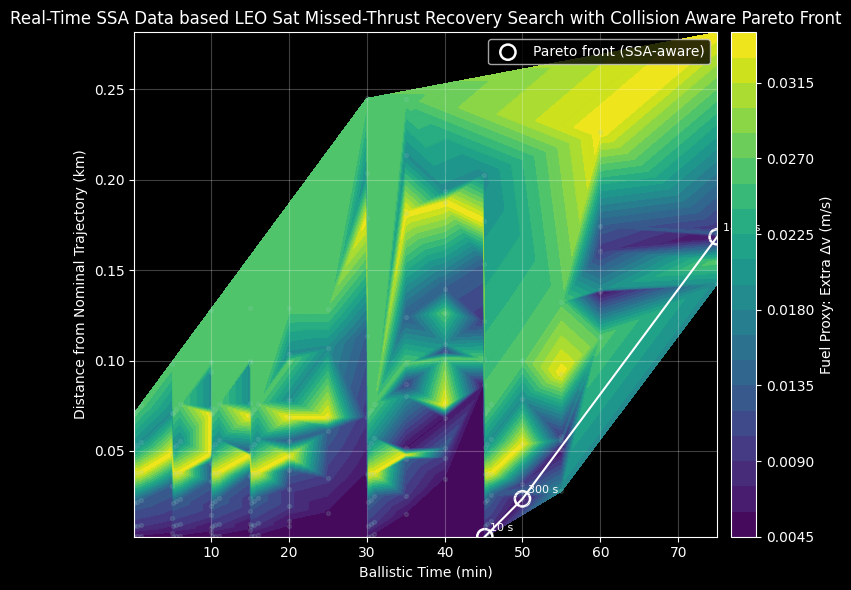

In [ ]:
# @title
# --- Block 8: Phase Guess search space with SSA-aware Pareto overlay ---

import matplotlib.pyplot as plt
import matplotlib.tri as mtri

plt.style.use("dark_background")

def pareto_front_ssa_aware(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy().reset_index(drop=True)

    obj = np.column_stack([
        -work["total_ballistic_min"].to_numpy(dtype=float),
         work["extra_dv_mps"].to_numpy(dtype=float),
         work["risk_proxy_peak"].to_numpy(dtype=float),
    ])

    keep = np.ones(len(work), dtype=bool)

    for i in range(len(work)):
        if not keep[i]:
            continue
        dominated = np.all(obj <= obj[i], axis=1) & np.any(obj < obj[i], axis=1)
        dominated[i] = False
        if np.any(dominated):
            keep[i] = False

    return work.loc[keep].copy().reset_index(drop=True)

SEARCH_SPACE_PLOT = PHASE_GUESS_SEARCH_SPACE.copy()
SEARCH_SPACE_PLOT["final_distance_km"] = SEARCH_SPACE_PLOT["terminal_position_error_km"]

SSA_SELECTED_PLOT = PHASE_GUESS_SELECTED_CANDIDATES.copy()
SSA_SELECTED_PLOT["final_distance_km"] = SSA_SELECTED_PLOT["terminal_position_error_km"]

SSA_AWARE_PARETO = pareto_front_ssa_aware(SSA_SELECTED_PLOT)
SSA_AWARE_PARETO = SSA_AWARE_PARETO.sort_values("total_ballistic_min").reset_index(drop=True)

x = SEARCH_SPACE_PLOT["total_ballistic_min"].to_numpy(dtype=float)
y = SEARCH_SPACE_PLOT["final_distance_km"].to_numpy(dtype=float)
z = SEARCH_SPACE_PLOT["extra_dv_mps"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(8, 6))

unique_xy = np.unique(np.column_stack([x, y]), axis=0)
if len(unique_xy) >= 3:
    tri = mtri.Triangulation(x, y)
    contour = ax.tricontourf(tri, z, levels=24)
    ax.tricontour(tri, z, levels=12, linewidths=0.4, alpha=0.4)
else:
    contour = ax.scatter(x, y, c=z, s=20)

# full search space points (light)
ax.scatter(x, y, s=8, alpha=0.15)

# Pareto front overlay
ax.scatter(
    SSA_AWARE_PARETO["total_ballistic_min"],
    SSA_AWARE_PARETO["final_distance_km"],
    s=120,
    facecolors="none",
    edgecolors="white",
    linewidths=1.8,
    label="Pareto front (SSA-aware)",
)

if len(SSA_AWARE_PARETO) >= 2:
    ax.plot(
        SSA_AWARE_PARETO["total_ballistic_min"],
        SSA_AWARE_PARETO["final_distance_km"],
        linewidth=1.5,
        color="white",
    )

# annotate outage values
for _, row in SSA_AWARE_PARETO.iterrows():
    ax.annotate(
        f"{int(row['outage_s'])} s",
        (row["total_ballistic_min"], row["final_distance_km"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

cbar = plt.colorbar(contour, ax=ax, pad=0.02)
cbar.set_label("Fuel Proxy: Extra Δv (m/s)")

ax.set_xlabel("Ballistic Time (min)")
ax.set_ylabel("Distance from Nominal Trajectory (km)")
ax.set_title("Real-Time SSA Data based LEO Sat Missed-Thrust Recovery Search with Collision Aware Pareto Front")

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()